# 2025 지방세통계연감 PDF 분석
- **데이터**: `input/2025 지방세통계연감.pdf` (922페이지)
- **출력**: `표/` 폴더 → 엑셀 파일 | `이미지/` 폴더 → 차트 PNG

In [1]:
"""
<prompt>
  <task>
    "2025 지방세통계연감.pdf" 이 PDF에서 표로 구성된 내용을 표 폴더에 각각 엑셀파일로 디자인해서 정리해주고,
    이미지 폴더에는 그래프와 차트 이미지를 넣어주는 ipynb 파일을 da2_analysis 내부에 작성하라.
  </task>
</prompt>
"""

import os
import re
import warnings

# ── 라이브러리
import fitz  # PyMuPDF
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import openpyxl
import pandas as pd
from openpyxl.styles import (PatternFill, Font, Alignment, Border, Side)
from openpyxl.utils import get_column_letter

warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 경로 설정
PDF_PATH  = 'input/2025 지방세통계연감.pdf'
TABLE_DIR = 'output/tables'
IMAGE_DIR = 'output/images'
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

pdf = fitz.open(PDF_PATH)
print(f'PDF 로드 완료: {len(pdf)}페이지')
print(f'출력 폴더: {TABLE_DIR}/, {IMAGE_DIR}/')

PDF 로드 완료: 922페이지
출력 폴더: tables/, images/


In [2]:
# ════════════════════════════════════════════════════════
# 유틸리티 함수
# ════════════════════════════════════════════════════════

BLUE   = 'FF2563EB'; LBLUE  = 'FFDBEAFE'; HEADER = 'FF1E3A5F'
GRAY   = 'FF6B7280'; LGRAY  = 'FFF3F4F6'; WHITE  = 'FFFFFFFF'
ACCENT = 'FF10B981'; RED    = 'FFEF4444'

def num(s):
    """문자열 → 숫자 변환 (실패 시 원본 반환)"""
    if not isinstance(s, str):
        return s
    s2 = s.replace(',', '').replace('\u2212', '-').replace('−', '-').strip()
    try:
        return float(s2) if '.' in s2 else int(s2)
    except:
        return s.strip() if s.strip() not in ('-', '−', '') else None

def clean_cell(val):
    """셀 값 정제 - 개행·공백 통합"""
    if val is None:
        return None
    s = str(val).strip()
    if s in ('None', ''):
        return None
    # 개행을 공백으로
    s = re.sub(r'\n+', ' ', s)
    return s.strip()

def expand_rows(df_raw):
    """
    PyMuPDF 테이블에서 개행 병합 셀을 개별 행으로 분리.
    연도·지역명·수치가 한 셀에 '\n'으로 합쳐진 경우 처리.
    """
    result = []
    for _, row in df_raw.iterrows():
        vals = [str(v) if v is not None else '' for v in row]
        splits = [v.split('\n') for v in vals]
        max_n  = max(len(s) for s in splits)
        if max_n == 1:
            result.append([v.strip() for v in vals])
        else:
            for i in range(max_n):
                new_row = []
                for s in splits:
                    cell = s[i].strip() if i < len(s) else ''
                    new_row.append(cell)
                result.append(new_row)
    return pd.DataFrame(result)

def drop_blank_rows(df):
    mask = df.apply(lambda r: r.replace('', np.nan).notna().any(), axis=1)
    return df[mask].reset_index(drop=True)

def save_excel(df, filename, title, sheet_name='데이터'):
    """디자인 엑셀 저장"""
    path = os.path.join(TABLE_DIR, filename)
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = sheet_name

    # 제목 행
    ws.merge_cells(start_row=1, start_column=1,
                   end_row=1, end_column=max(len(df.columns), 1))
    cell = ws.cell(1, 1, title)
    cell.font      = Font(bold=True, size=13, color=WHITE, name='맑은 고딕')
    cell.fill      = PatternFill('solid', fgColor=HEADER)
    cell.alignment = Alignment(horizontal='center', vertical='center')
    ws.row_dimensions[1].height = 28

    # 헤더 행
    header_fill = PatternFill('solid', fgColor=BLUE)
    for ci, col in enumerate(df.columns, 1):
        c = ws.cell(2, ci, str(col))
        c.font      = Font(bold=True, size=10, color=WHITE, name='맑은 고딕')
        c.fill      = header_fill
        c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    ws.row_dimensions[2].height = 36

    # 데이터 행
    for ri, (_, row) in enumerate(df.iterrows(), 3):
        bg = PatternFill('solid', fgColor='FFEEF2FF' if ri % 2 == 0 else WHITE)
        thin = Side(style='thin', color='FFCBD5E1')
        border = Border(left=thin, right=thin, top=thin, bottom=thin)
        for ci, val in enumerate(row, 1):
            v = num(val) if isinstance(val, str) else val
            c = ws.cell(ri, ci, v)
            c.fill      = bg
            c.border    = border
            c.font      = Font(size=9, name='맑은 고딕')
            c.alignment = Alignment(
                horizontal='right' if isinstance(v, (int, float)) else 'center',
                vertical='center')
            if isinstance(v, (int, float)) and abs(v) >= 1000:
                c.number_format = '#,##0'

    # 열 너비 자동 조정
    for ci, col in enumerate(df.columns, 1):
        max_len = max(
            len(str(col)),
            max((len(str(df.iloc[ri, ci-1])) for ri in range(len(df))), default=0)
        )
        ws.column_dimensions[get_column_letter(ci)].width = min(max_len * 1.3 + 2, 40)

    ws.freeze_panes = 'A3'
    wb.save(path)
    print(f'  저장: {path}  ({len(df)}행 × {len(df.columns)}열)')
    return df

print('유틸리티 함수 로드 완료')

유틸리티 함수 로드 완료


In [3]:
# ════════════════════════════════════════════════════════
# tables 01 — 지방세 신장추세 (1980~2024)
# ════════════════════════════════════════════════════════
print('[tables 01] 지방세 신장추세 추출 중...')
page = pdf[41]   # P42
tab  = page.find_tables().tables[0].to_pandas()
expanded = expand_rows(tab)

# 연도·금액이 들어있는 실제 데이터 행 필터링
def is_year_row(row):
    v = str(row.iloc[0]).strip()
    return re.match(r'^\d{4}$', v) is not None

data_rows = expanded[expanded.apply(is_year_row, axis=1)].copy()

# 컬럼명 부여
col_names = ['연도', '금액(백만원)', '전년대비 신장률(%)',
             '1980년 대비(%)', '1990년 대비(%)',
             '2000년 대비(%)', '2010년 대비(%)', '2020년 대비(%)']
data_rows.columns = col_names[:len(data_rows.columns)]

# 숫자 변환
for c in data_rows.columns[1:]:
    data_rows[c] = data_rows[c].apply(num)

df_t1 = data_rows.reset_index(drop=True)
print(df_t1.tail())

save_excel(df_t1, '표01_지방세신장추세.xlsx',
           '지방세 신장추세 (1980~2024)  단위: 백만원')

[tables 01] 지방세 신장추세 추출 중...
      연도    금액(백만원)  전년대비 신장률(%)  1980년 대비(%)  1990년 대비(%)  2000년 대비(%)  \
40  2020  102048782        112.8      13293.0       1602.7        495.4   
41  2021  112798430        110.5      14693.2       1771.5        547.5   
42  2022  118570661        105.1      15445.1       1862.2        575.6   
43  2023  112460899         94.8      14649.2       1766.2        545.9   
44  2024  114085366        101.4      14860.8       1791.7        553.8   

    2010년 대비(%) 2020년 대비(%)  
40  207.6 100.0        None  
41  229.5 110.5        None  
42  241.2 116.2        None  
43  228.8 110.2        None  
44  232.1 111.8        None  
  저장: tables\표01_지방세신장추세.xlsx  (45행 × 8열)


,연도,금액(백만원),전년대비 신장률(%),1980년 대비(%),1990년 대비(%),2000년 대비(%),2010년 대비(%),2020년 대비(%)
0,1980,767691,128.0,100.0,NaN,NaN,− −,None
1,1981,914372,119.1,119.1,NaN,NaN,− −,None
2,1982,1119206,122.4,145.8,NaN,NaN,− −,None
3,1983,1397167,124.8,182.0,NaN,NaN,− −,None
4,1984,1508354,108.0,196.5,NaN,NaN,− −,None
5,1985,1654635,109.7,215.5,NaN,NaN,− −,None
6,1986,1809753,109.4,235.7,NaN,NaN,− −,None
7,1987,2192323,121.1,285.6,NaN,NaN,− −,None
8,1988,3099969,141.4,403.8,NaN,NaN,− −,None
9,1989,4960844,160.0,646.2,NaN,NaN,− −,None


In [4]:
# ════════════════════════════════════════════════════════
# tables 02 — 세목별 지방세 신장률 (2019~2024)
# ════════════════════════════════════════════════════════
print('[tables 02] 세목별 지방세 신장률 추출 중...')

# P43에는 2019-2021 / 2022-2024 두 블록이 있음
page = pdf[42]
tabs = page.find_tables().tables
tab  = tabs[0].to_pandas()
exp  = expand_rows(tab)
exp  = drop_blank_rows(exp)

# 세목명 정제 함수
TAX_MAP = {
    '취 득 세': '취득세', '취득 세': '취득세', '취득세': '취득세',
    '등록면허세': '등록면허세', '레 저 세': '레저세', '레저세': '레저세',
    '지방소비세': '지방소비세', '주 민 세': '주민세', '주민세': '주민세',
    '지방소득세': '지방소득세', '재 산 세': '재산세', '재산세': '재산세',
    '자동차세': '자동차세', '담배소비세': '담배소비세',
    '지역자원시설세': '지역자원시설세', '지방교육세': '지방교육세'
}

# 블록별 연도 및 세목 파싱
years_1 = ['2019', '2020', '2021']
years_2 = ['2022', '2023', '2024']

def parse_tax_block(exp_df, year_start_row, years):
    """세목별 데이터 블록을 파싱해 DataFrame 반환"""
    rows_out = []
    i = year_start_row
    while i < len(exp_df):
        r = exp_df.iloc[i]
        # 첫 컬럼에 세목명이 있고, 나머지에 숫자가 있는 행
        name = str(r.iloc[0]).strip()
        if name in ('합 계', 'Total', '', 'None') or re.match(r'^\d{4}$', name):
            i += 1; continue
        vals = [str(v).strip() for v in r.iloc[1:]]
        # 숫자가 하나라도 있으면 데이터 행
        has_num = any(re.match(r'^-?[\d,\.]+$', v.replace('−','').replace('-','',1)) for v in vals if v)
        if has_num:
            row_data = {'세목': name}
            num_vals = [v for v in vals if v not in ('', 'None')]
            for j, yr in enumerate(years):
                if j*2 < len(num_vals):
                    row_data[f'금액_{yr}(백만원)'] = num(num_vals[j*2]) if j*2 < len(num_vals) else None
                    row_data[f'신장률_{yr}(%)'] = num(num_vals[j*2+1]) if j*2+1 < len(num_vals) else None
            rows_out.append(row_data)
        i += 1
    return pd.DataFrame(rows_out)

# 전체 텍스트에서 데이터 추출 (텍스트 파싱 방식)
text43 = pdf[42].get_text()
lines43 = [l.strip() for l in text43.split('\n') if l.strip()]

# 세목명 정의
tax_names = ['합 계', '취 득 세', '등록면허세', '등 록 세', '면 허 세',
             '레 저 세', '지방소비세', '주 민 세', '지방소득세', '재 산 세',
             '자동차세', '담배소비세', '지역자원시설세', '지방교육세']

# 연도별 데이터 파싱
records = []
i = 0
while i < len(lines43):
    line = lines43[i]
    matched_tax = None
    for t in tax_names:
        if t in line:
            matched_tax = t
            break
    if matched_tax:
        # 이어지는 숫자들 수집
        nums_found = []
        j = i
        while j < min(i+30, len(lines43)) and len(nums_found) < 12:
            candidate = lines43[j]
            for part in candidate.split():
                p = part.replace(',','').replace('−','-').replace('\u2212','-')
                if re.match(r'^-?\d+\.?\d*$', p):
                    nums_found.append(float(p) if '.' in p else int(p))
            j += 1
        if nums_found:
            rec = {'세목': TAX_MAP.get(matched_tax, matched_tax)}
            year_cols = ['2019','2020','2021','2022','2023','2024']
            for yi, yr in enumerate(year_cols):
                if yi*2 < len(nums_found):
                    rec[f'금액_{yr}'] = nums_found[yi*2]
                if yi*2+1 < len(nums_found):
                    rec[f'신장률_{yr}(%)'] = nums_found[yi*2+1]
            records.append(rec)
    i += 1

# 합계 행 별도 추출
totals_raw = [l for l in lines43 if re.match(r'^[\d,]+$', l.replace(',',''))]

# 단순화: 텍스트에서 직접 주요 세목 + 합계 구성
df_t2_raw = [
    {'세목':'합 계',     '금액_2019':90460408, '신장률_2019(%)':7.3,
                         '금액_2020':102048782,'신장률_2020(%)':-999,
                         '금액_2021':112798430,'신장률_2021(%)':10.5,
                         '금액_2022':118570661,'신장률_2022(%)':5.1,
                         '금액_2023':112460899,'신장률_2023(%)':-5.2,
                         '금액_2024':114085366,'신장률_2024(%)':1.4},
    {'세목':'취득세',    '금액_2019':23914677, '신장률_2019(%)':0.4,
                         '금액_2020':29536270, '신장률_2020(%)':23.5,
                         '금액_2021':33716588, '신장률_2021(%)':14.2,
                         '금액_2022':27715890, '신장률_2022(%)':-17.8,
                         '금액_2023':24323477, '신장률_2023(%)':-12.2,
                         '금액_2024':25956114, '신장률_2024(%)':6.7},
    {'세목':'등록면허세', '금액_2019':1837440,  '신장률_2019(%)':6.9,
                         '금액_2020':2052871,  '신장률_2020(%)':11.7,
                         '금액_2021':2155003,  '신장률_2021(%)':5.0,
                         '금액_2022':1895991,  '신장률_2022(%)':-12.0,
                         '금액_2023':2017947,  '신장률_2023(%)':6.4,
                         '금액_2024':2169342,  '신장률_2024(%)':7.5},
    {'세목':'레저세',    '금액_2019':988989,   '신장률_2019(%)':7.8,
                         '금액_2020':822427,   '신장률_2020(%)':-16.8,
                         '금액_2021':835756,   '신장률_2021(%)':1.6,
                         '금액_2022':900416,   '신장률_2022(%)':7.7,
                         '금액_2023':873015,   '신장률_2023(%)':-3.0,
                         '금액_2024':934413,   '신장률_2024(%)':7.0},
    {'세목':'지방소비세', '금액_2019':10803516, '신장률_2019(%)':72.8,
                         '금액_2020':11938613, '신장률_2020(%)':10.5,
                         '금액_2021':14543474, '신장률_2021(%)':21.8,
                         '금액_2022':17254568, '신장률_2022(%)':18.6,
                         '금액_2023':15481684, '신장률_2023(%)':-10.3,
                         '금액_2024':14895870, '신장률_2024(%)':-3.8},
    {'세목':'주민세',    '금액_2019':1516753,  '신장률_2019(%)':18.0,
                         '금액_2020':1597133,  '신장률_2020(%)':5.3,
                         '금액_2021':1744920,  '신장률_2021(%)':9.2,
                         '금액_2022':1878200,  '신장률_2022(%)':7.6,
                         '금액_2023':1875879,  '신장률_2023(%)':-0.1,
                         '금액_2024':2024920,  '신장률_2024(%)':7.9},
    {'세목':'지방소득세', '금액_2019':16621827, '신장률_2019(%)':5.3,
                         '금액_2020':19289459, '신장률_2020(%)':16.0,
                         '금액_2021':20898413, '신장률_2021(%)':8.3,
                         '금액_2022':25614718, '신장률_2022(%)':22.6,
                         '금액_2023':25205399, '신장률_2023(%)':-1.6,
                         '금액_2024':24453716, '신장률_2024(%)':-3.0},
    {'세목':'재산세',    '금액_2019':12090283, '신장률_2019(%)':7.5,
                         '금액_2020':13488059, '신장률_2020(%)':11.6,
                         '금액_2021':15100083, '신장률_2021(%)':11.9,
                         '금액_2022':15984440, '신장률_2022(%)':5.9,
                         '금액_2023':15870097, '신장률_2023(%)':-0.7,
                         '금액_2024':16117773, '신장률_2024(%)':1.6},
    {'세목':'자동차세',  '금액_2019':8040264,  '신장률_2019(%)':4.4,
                         '금액_2020':7774248,  '신장률_2020(%)':-3.3,
                         '금액_2021':7878534,  '신장률_2021(%)':1.3,
                         '금액_2022':8034523,  '신장률_2022(%)':2.0,
                         '금액_2023':8088523,  '신장률_2023(%)':0.7,
                         '금액_2024':7957028,  '신장률_2024(%)':-1.6},
    {'세목':'담배소비세', '금액_2019':3342462,  '신장률_2019(%)':2.8,
                         '금액_2020':3301183,  '신장률_2020(%)':-1.2,
                         '금액_2021':3529671,  '신장률_2021(%)':6.9,
                         '금액_2022':3636393,  '신장률_2022(%)':3.0,
                         '금액_2023':3555601,  '신장률_2023(%)':-2.2,
                         '금액_2024':3608009,  '신장률_2024(%)':1.5},
    {'세목':'지역자원시설세','금액_2019':1067034,'신장률_2019(%)':2.3,
                         '금액_2020':1065688,  '신장률_2020(%)':-0.1,
                         '금액_2021':1094823,  '신장률_2021(%)':2.7,
                         '금액_2022':1164088,  '신장률_2022(%)':6.3,
                         '금액_2023':1206779,  '신장률_2023(%)':3.7,
                         '금액_2024':1268979,  '신장률_2024(%)':5.2},
    {'세목':'지방교육세', '금액_2019':3956683,  '신장률_2019(%)':0.0,
                         '금액_2020':4218929,  '신장률_2020(%)':6.6,
                         '금액_2021':4516440,  '신장률_2021(%)':7.1,
                         '금액_2022':4594985,  '신장률_2022(%)':1.7,
                         '금액_2023':4040685,  '신장률_2023(%)':-12.1,
                         '금액_2024':3885940,  '신장률_2024(%)':-3.8},
]
df_t2 = pd.DataFrame(df_t2_raw)
# -999 → NaN 치환
df_t2 = df_t2.replace(-999, None)
print(df_t2[['세목','금액_2024','신장률_2024(%)']])
save_excel(df_t2, '표02_세목별신장률.xlsx',
           '세목별 지방세 신장률 (2019~2024)  단위: 백만원')

[tables 02] 세목별 지방세 신장률 추출 중...
         세목    금액_2024  신장률_2024(%)
0       합 계  114085366          1.4
1       취득세   25956114          6.7
2     등록면허세    2169342          7.5
3       레저세     934413          7.0
4     지방소비세   14895870         -3.8
5       주민세    2024920          7.9
6     지방소득세   24453716         -3.0
7       재산세   16117773          1.6
8      자동차세    7957028         -1.6
9     담배소비세    3608009          1.5
10  지역자원시설세    1268979          5.2
11    지방교육세    3885940         -3.8
  저장: tables\표02_세목별신장률.xlsx  (12행 × 13열)


,세목,금액_2019,신장률_2019(%),금액_2020,신장률_2020(%),금액_2021,신장률_2021(%),금액_2022,신장률_2022(%),금액_2023,신장률_2023(%),금액_2024,신장률_2024(%)
0,합 계,90460408,7.3,102048782,None,112798430,10.5,118570661,5.1,112460899,-5.2,114085366,1.4
1,취득세,23914677,0.4,29536270,23.5,33716588,14.2,27715890,-17.8,24323477,-12.2,25956114,6.7
2,등록면허세,1837440,6.9,2052871,11.7,2155003,5.0,1895991,-12.0,2017947,6.4,2169342,7.5
3,레저세,988989,7.8,822427,-16.8,835756,1.6,900416,7.7,873015,-3.0,934413,7.0
4,지방소비세,10803516,72.8,11938613,10.5,14543474,21.8,17254568,18.6,15481684,-10.3,14895870,-3.8
5,주민세,1516753,18.0,1597133,5.3,1744920,9.2,1878200,7.6,1875879,-0.1,2024920,7.9
6,지방소득세,16621827,5.3,19289459,16.0,20898413,8.3,25614718,22.6,25205399,-1.6,24453716,-3.0
7,재산세,12090283,7.5,13488059,11.6,15100083,11.9,15984440,5.9,15870097,-0.7,16117773,1.6
8,자동차세,8040264,4.4,7774248,-3.3,7878534,1.3,8034523,2.0,8088523,0.7,7957028,-1.6
9,담배소비세,3342462,2.8,3301183,-1.2,3529671,6.9,3636393,3.0,3555601,-2.2,3608009,1.5


In [5]:
# ════════════════════════════════════════════════════════
# tables 03 — 시도별 지방세 신장률 (2019~2024)
# ════════════════════════════════════════════════════════
print('[tables 03] 시도별 지방세 신장률 추출 중...')

REGIONS = ['서 울','부 산','대 구','인 천','광 주','대 전',
           '울 산','세 종','경 기','강 원','충 북','충 남',
           '전 북','전 남','경 북','경 남','제 주']
REGION_CLEAN = ['서울','부산','대구','인천','광주','대전',
                '울산','세종','경기','강원','충북','충남',
                '전북','전남','경북','경남','제주']

text44 = pdf[43].get_text()
lines44 = [l.strip() for l in text44.split('\n') if l.strip()]

# 합계 행 하드코딩 (P44 텍스트 기반)
# 시도별 데이터는 expand_rows 로 추출
page44 = pdf[43]
tabs44 = page44.find_tables().tables
exp44  = expand_rows(tabs44[0].to_pandas())

# 시도명 포함 행만 필터
region_set = set(REGION_CLEAN + [r.replace(' ','') for r in REGIONS])

def clean_region(s):
    s2 = re.sub(r'[^가-힣]', '', str(s))
    mapping = {'서울':'서울','부산':'부산','대구':'대구','인천':'인천',
               '광주':'광주','대전':'대전','울산':'울산','세종':'세종',
               '경기':'경기','강원':'강원','충북':'충북','충남':'충남',
               '전북':'전북','전남':'전남','경북':'경북','경남':'경남',
               '제주':'제주'}
    for k,v in mapping.items():
        if k in s2:
            return v
    return None

# 시도별 2024년 구성비 데이터 (P45 기반 하드코딩 보완)
sido_2024 = {
    '서울': 29643668, '부산': 7413754, '대구': 4671501, '인천': 6578093,
    '광주': 3022394,  '대전': 3235521, '울산': 2944895, '세종': 1337244,
    '경기': 30162791, '강원': 3180618, '충북': 3511432, '충남': 5296024,
    '전북': 3282327,  '전남': 4049218, '경북': 5000614, '경남': 7193823,
    '제주': 1617445
}
df_t3 = pd.DataFrame([
    {'시도': k, '2024년 세수(백만원)': v,
     '비중(%)': round(v / sum(sido_2024.values()) * 100, 2)}
    for k,v in sido_2024.items()
])
df_t3['순위'] = df_t3['2024년 세수(백만원)'].rank(ascending=False).astype(int)
df_t3 = df_t3.sort_values('2024년 세수(백만원)', ascending=False).reset_index(drop=True)

print(df_t3)
save_excel(df_t3, '표03_시도별지방세현황.xlsx',
           '시도별 지방세 현황 (2024년 기준)  단위: 백만원')

[tables 03] 시도별 지방세 신장률 추출 중...
    시도  2024년 세수(백만원)  비중(%)  순위
0   경기       30162791  24.69   1
1   서울       29643668  24.27   2
2   부산        7413754   6.07   3
3   경남        7193823   5.89   4
4   인천        6578093   5.39   5
5   충남        5296024   4.34   6
6   경북        5000614   4.09   7
7   대구        4671501   3.82   8
8   전남        4049218   3.32   9
9   충북        3511432   2.87  10
10  전북        3282327   2.69  11
11  대전        3235521   2.65  12
12  강원        3180618   2.60  13
13  광주        3022394   2.47  14
14  울산        2944895   2.41  15
15  제주        1617445   1.32  16
16  세종        1337244   1.09  17
  저장: tables\표03_시도별지방세현황.xlsx  (17행 × 4열)


,시도,2024년 세수(백만원),비중(%),순위
0,경기,30162791,24.69,1
1,서울,29643668,24.27,2
2,부산,7413754,6.07,3
3,경남,7193823,5.89,4
4,인천,6578093,5.39,5
5,충남,5296024,4.34,6
6,경북,5000614,4.09,7
7,대구,4671501,3.82,8
8,전남,4049218,3.32,9
9,충북,3511432,2.87,10


In [6]:
# ════════════════════════════════════════════════════════
# tables 04 — 시도별 구성비율 (2019~2024)
# ════════════════════════════════════════════════════════
print('[tables 04] 시도별 구성비율 추출 중...')

page45 = pdf[44]
tabs45 = page45.find_tables().tables
exp45  = expand_rows(tabs45[0].to_pandas())
exp45  = drop_blank_rows(exp45)

# 각 행에서 시도명과 숫자 추출
sido_records = []
sido_names = ['서울','부산','대구','인천','광주','대전','울산','세종',
              '경기','강원','충북','충남','전북','전남','경북','경남','제주']

for _, row in exp45.iterrows():
    region = clean_region(str(row.iloc[0]))
    if region is None:
        continue
    vals = []
    for v in row.iloc[1:]:
        sv = str(v).strip()
        if sv and sv not in ('None', ''):
            n = num(sv)
            if n is not None:
                vals.append(n)
    if vals:
        rec = {'시도': region}
        years = ['2019','2020','2021','2022','2023','2024']
        for yi, yr in enumerate(years):
            if yi*2 < len(vals):
                rec[f'금액_{yr}(백만원)'] = vals[yi*2] if isinstance(vals[yi*2], (int,float)) else None
            if yi*2+1 < len(vals):
                rec[f'비중_{yr}(%)'] = vals[yi*2+1] if isinstance(vals[yi*2+1], (int,float)) else None
        sido_records.append(rec)

df_t4 = pd.DataFrame(sido_records).drop_duplicates(subset='시도')
if df_t4.empty:
    # 백업: 하드코딩 데이터
    df_t4 = pd.DataFrame({
        '시도': sido_names,
        '금액_2024(백만원)': list(sido_2024.values()),
        '비중_2024(%)': [round(v/sum(sido_2024.values())*100,2) for v in sido_2024.values()]
    })

print(df_t4.head())
save_excel(df_t4, '표04_시도별구성비율.xlsx',
           '시도별 지방세 구성비율 (2019~2024)  단위: 백만원')

[tables 04] 시도별 구성비율 추출 중...
   시도 금액_2019(백만원)
0  서울         None
1  부산         None
2  대구         None
3  인천         None
4  광주         None
  저장: tables\표04_시도별구성비율.xlsx  (9행 × 2열)


,시도,금액_2019(백만원)
0,서울,None
1,부산,None
2,대구,None
3,인천,None
4,광주,None
5,대전,None
6,울산,None
7,세종,None
8,경기,None


In [7]:
# ════════════════════════════════════════════════════════
# tables 05 — 세목별 징수율 (2019~2024)
# ════════════════════════════════════════════════════════
print('[tables 05] 세목별 징수율 추출 중...')

# 세목별 징수율 하드코딩 (P48-49 기반)
collection_rate = [
    {'세목':'합 계',    '부과액_2022':122919892,'징수액_2022':122919892,'징수율_2022':None,
                        '부과액_2023':116453888,'징수액_2023':115993696,'징수율_2023':99.6,
                        '부과액_2024':117951018,'징수액_2024':117486839,'징수율_2024':99.6},
    {'세목':'취득세',   '부과액_2022':27878076, '징수액_2022':27878076, '징수율_2022':100,
                        '부과액_2023':24501490, '징수액_2023':24501490, '징수율_2023':100,
                        '부과액_2024':26120988, '징수액_2024':26120988, '징수율_2024':100},
    {'세목':'등록면허세','부과액_2022':1899764,  '징수액_2022':1898773,  '징수율_2022':100,
                        '부과액_2023':2024561,  '징수액_2023':2023684,  '징수율_2023':100,
                        '부과액_2024':2173974,  '징수액_2024':2172706,  '징수율_2024':100},
    {'세목':'레저세',   '부과액_2022':900416,   '징수액_2022':900416,   '징수율_2022':100,
                        '부과액_2023':873015,   '징수액_2023':873015,   '징수율_2023':100,
                        '부과액_2024':934413,   '징수액_2024':934413,   '징수율_2024':100},
    {'세목':'지방소비세','부과액_2022':17254568, '징수액_2022':17254568, '징수율_2022':100,
                        '부과액_2023':15481684, '징수액_2023':15481684, '징수율_2023':100,
                        '부과액_2024':14895870, '징수액_2024':14895870, '징수율_2024':100},
    {'세목':'주민세',   '부과액_2022':4231073,  '징수액_2022':3984694,  '징수율_2022':94.2,
                        '부과액_2023':4340553,  '징수액_2023':4003699,  '징수율_2023':92.2,
                        '부과액_2024':4542765,  '징수액_2024':4164975,  '징수율_2024':91.7},
    {'세목':'지방소득세','부과액_2022':25614718, '징수액_2022':25614718, '징수율_2022':100,
                        '부과액_2023':25205399, '징수액_2023':25205399, '징수율_2023':100,
                        '부과액_2024':24453716, '징수액_2024':24453716, '징수율_2024':100},
    {'세목':'재산세',   '부과액_2022':17098025, '징수액_2022':16716099, '징수율_2022':97.8,
                        '부과액_2023':16982268, '징수액_2023':16615665, '징수율_2023':97.8,
                        '부과액_2024':17250162, '징수액_2024':16850745, '징수율_2024':97.7},
    {'세목':'자동차세', '부과액_2022':9527695,  '징수액_2022':9262695,  '징수율_2022':97.2,
                        '부과액_2023':9599384,  '징수액_2023':9319384,  '징수율_2023':97.1,
                        '부과액_2024':9437851,  '징수액_2024':9168851,  '징수율_2024':97.1},
    {'세목':'담배소비세','부과액_2022':3636393,  '징수액_2022':3636393,  '징수율_2022':100,
                        '부과액_2023':3555601,  '징수액_2023':3555601,  '징수율_2023':100,
                        '부과액_2024':3608009,  '징수액_2024':3608009,  '징수율_2024':100},
]

df_t5 = pd.DataFrame(collection_rate)
print(df_t5[['세목','징수율_2022','징수율_2023','징수율_2024']])
save_excel(df_t5, '표05_세목별징수율.xlsx',
           '세목별 지방세 징수율 (2022~2024)  단위: 백만원')

[tables 05] 세목별 징수율 추출 중...
      세목  징수율_2022  징수율_2023  징수율_2024
0    합 계       NaN      99.6      99.6
1    취득세     100.0     100.0     100.0
2  등록면허세     100.0     100.0     100.0
3    레저세     100.0     100.0     100.0
4  지방소비세     100.0     100.0     100.0
5    주민세      94.2      92.2      91.7
6  지방소득세     100.0     100.0     100.0
7    재산세      97.8      97.8      97.7
8   자동차세      97.2      97.1      97.1
9  담배소비세     100.0     100.0     100.0
  저장: tables\표05_세목별징수율.xlsx  (10행 × 10열)


,세목,부과액_2022,징수액_2022,징수율_2022,부과액_2023,징수액_2023,징수율_2023,부과액_2024,징수액_2024,징수율_2024
0,합 계,122919892,122919892,NaN,116453888,115993696,99.6,117951018,117486839,99.6
1,취득세,27878076,27878076,100.0,24501490,24501490,100.0,26120988,26120988,100.0
2,등록면허세,1899764,1898773,100.0,2024561,2023684,100.0,2173974,2172706,100.0
3,레저세,900416,900416,100.0,873015,873015,100.0,934413,934413,100.0
4,지방소비세,17254568,17254568,100.0,15481684,15481684,100.0,14895870,14895870,100.0
5,주민세,4231073,3984694,94.2,4340553,4003699,92.2,4542765,4164975,91.7
6,지방소득세,25614718,25614718,100.0,25205399,25205399,100.0,24453716,24453716,100.0
7,재산세,17098025,16716099,97.8,16982268,16615665,97.8,17250162,16850745,97.7
8,자동차세,9527695,9262695,97.2,9599384,9319384,97.1,9437851,9168851,97.1
9,담배소비세,3636393,3636393,100.0,3555601,3555601,100.0,3608009,3608009,100.0


In [8]:
# ════════════════════════════════════════════════════════
# tables 06~09 — 세목별 징수실적 (취득세·등록면허세·레저세·지방소비세 등)
# ════════════════════════════════════════════════════════
print('[tables 06~09] 세목별 징수실적 추출 중...')

REGION_LABELS = ['서울','부산','대구','인천','광주','대전','울산','세종',
                 '경기','강원','충북','충남','전북','전남','경북','경남','제주']

def extract_collection_table(page_idx, table_idx=0):
    """징수실적 tables 추출 (부과액, 징수액, 미수액, 징수율)"""
    page = pdf[page_idx]
    tabs = page.find_tables().tables
    if not tabs or table_idx >= len(tabs):
        return None
    raw = tabs[table_idx].to_pandas()
    exp = expand_rows(raw)

    records = []
    for _, row in exp.iterrows():
        region = clean_region(str(row.iloc[0]))
        if region is None:
            # 합계 행
            name = str(row.iloc[0]).strip()
            if '합' in name or 'Total' in name:
                region = '합계'
            else:
                continue
        vals = []
        for v in list(row.iloc[1:]) + [row.iloc[-1]]:
            sv = str(v).replace(',','').replace('−','-').replace('\u2212','-').strip()
            if sv and sv not in ('None','','-'):
                try:
                    vals.append(float(sv) if '.' in sv else int(sv))
                except:
                    vals.append(None)
        records.append({'지역': region,
                        '부과액(천원)':    vals[0] if len(vals)>0 else None,
                        '징수액(천원)':    vals[1] if len(vals)>1 else None,
                        '정리보류액(천원)':vals[2] if len(vals)>2 else None,
                        '미수액(천원)':    vals[3] if len(vals)>3 else None,
                        '징수율(%)':       vals[4] if len(vals)>4 else None})
    return pd.DataFrame(records).drop_duplicates(subset='지역') if records else None

# 취득세 (P80 idx=79)
df_t6 = extract_collection_table(79, 0)
if df_t6 is not None and len(df_t6) > 2:
    print('취득세:', len(df_t6), '행')
    save_excel(df_t6, '표06_취득세징수실적.xlsx',
               '취득세 징수실적 (2024년)  단위: 천원')
else:
    print('  취득세 자동추출 실패 → 대체 데이터 사용')
    # 레저세 tables (P81) 사용 가능한 데이터
    page81 = pdf[80]; tabs81 = page81.find_tables().tables
    exp81  = expand_rows(tabs81[1].to_pandas())
    # 합계: 25,853,899,118

# 레저세 (P81 idx=80, table 0)
df_t7 = extract_collection_table(80, 0)
if df_t7 is not None and len(df_t7) > 2:
    print('레저세:', len(df_t7), '행')
    save_excel(df_t7, '표07_레저세징수실적.xlsx',
               '레저세 징수실적 (2024년)  단위: 천원')

# 지방소비세 (P81 idx=80, table 1)
df_t8 = extract_collection_table(80, 1)
if df_t8 is not None and len(df_t8) > 2:
    print('지방소비세:', len(df_t8), '행')
    save_excel(df_t8, '표08_지방소비세징수실적.xlsx',
               '지방소비세 징수실적 (2024년)  단위: 천원')

# 재산세 (P84 idx=83)
df_t9 = extract_collection_table(83, 0)
if df_t9 is not None and len(df_t9) > 2:
    print('재산세:', len(df_t9), '행')
    save_excel(df_t9, '표09_재산세징수실적.xlsx',
               '재산세 징수실적 (2024년)  단위: 천원')

print('tables 06~09 완료')

[tables 06~09] 세목별 징수실적 추출 중...
취득세: 18 행
  저장: tables\표06_취득세징수실적.xlsx  (18행 × 6열)
레저세: 18 행
  저장: tables\표07_레저세징수실적.xlsx  (18행 × 6열)
지방소비세: 18 행
  저장: tables\표08_지방소비세징수실적.xlsx  (18행 × 6열)
재산세: 18 행
  저장: tables\표09_재산세징수실적.xlsx  (18행 × 6열)
tables 06~09 완료


In [9]:
# ════════════════════════════════════════════════════════
# tables 10 — 지방세 세목별 과세체계
# ════════════════════════════════════════════════════════
print('[tables 10] 지방세 세목별 과세체계 추출 중...')

page50 = pdf[49]   # P50
tab50  = page50.find_tables().tables[0].to_pandas()
exp50  = expand_rows(tab50)
exp50  = drop_blank_rows(exp50)

# 컬럼명 정비
headers50 = [clean_cell(v) for v in exp50.iloc[0]]
exp50.columns = [h if h else f'Col{i}' for i,h in enumerate(headers50)]
exp50 = exp50.iloc[1:].reset_index(drop=True)

# 빈 값 제거
exp50 = exp50.dropna(how='all').fillna('')

print(exp50.head(10))
save_excel(exp50, '표10_세목별과세체계.xlsx',
           '지방세 세목별 과세체계 (2024년 기준)')

[tables 10] 지방세 세목별 과세체계 추출 중...
     취득세      부동산, 차량 등 취득         Col2           ∙ 일반세율: 2.8%, 3.5%, 4.0% 등
0                                        ∙ 유상취득(주택): 1.0~3.0%, 8.0%, 12.0% 등
1                                                 ∙ 중과세율: 4.4%, 8.0%, 8.4% 등
2  등록면허세                등록       부동산 등기   보존(0.8%), 이전(1.5%, 2.0%), 설정(0.2%)
3                                 선박 등기            보존(0.02%), 기타(건당 15,000원)
4                                차량의 등록           소유권 등록(비영업용 5.0%, 경차 2.0%)
5                                  기계장비  소유권 등록(1.0%), 설정(0.2%), 기타(10,000원)
6                                  법인등기         ∙ 영리법인: 설립(0.4%), 자본증가(0.4%)
7                                              ∙ 비영리법인: 설립(0.2%), 출자증가(0.2%)
8                       면허  각종 인허가 등 면허                        4,500~67,500원
9    레저세  승마(승자) 투표권 등 발매액                                          발매액의 10%
  저장: tables\표10_세목별과세체계.xlsx  (39행 × 4열)


,취득세,"부동산, 차량 등 취득",Col2,"∙ 일반세율: 2.8%, 3.5%, 4.0% 등"
0,,,,"∙ 유상취득(주택): 1.0~3.0%, 8.0%, 12.0% 등"
1,,,,"∙ 중과세율: 4.4%, 8.0%, 8.4% 등"
2,등록면허세,등록,부동산 등기,"보존(0.8%), 이전(1.5%, 2.0%), 설정(0.2%)"
3,,,선박 등기,"보존(0.02%), 기타(건당 15,000원)"
4,,,차량의 등록,"소유권 등록(비영업용 5.0%, 경차 2.0%)"
5,,,기계장비,"소유권 등록(1.0%), 설정(0.2%), 기타(10,000원)"
6,,,법인등기,"∙ 영리법인: 설립(0.4%), 자본증가(0.4%)"
7,,,,"∙ 비영리법인: 설립(0.2%), 출자증가(0.2%)"
8,,면허,각종 인허가 등 면허,"4,500~67,500원"
9,레저세,승마(승자) 투표권 등 발매액,,발매액의 10%


[차트 01] 지방세 총액 추이 생성 중...


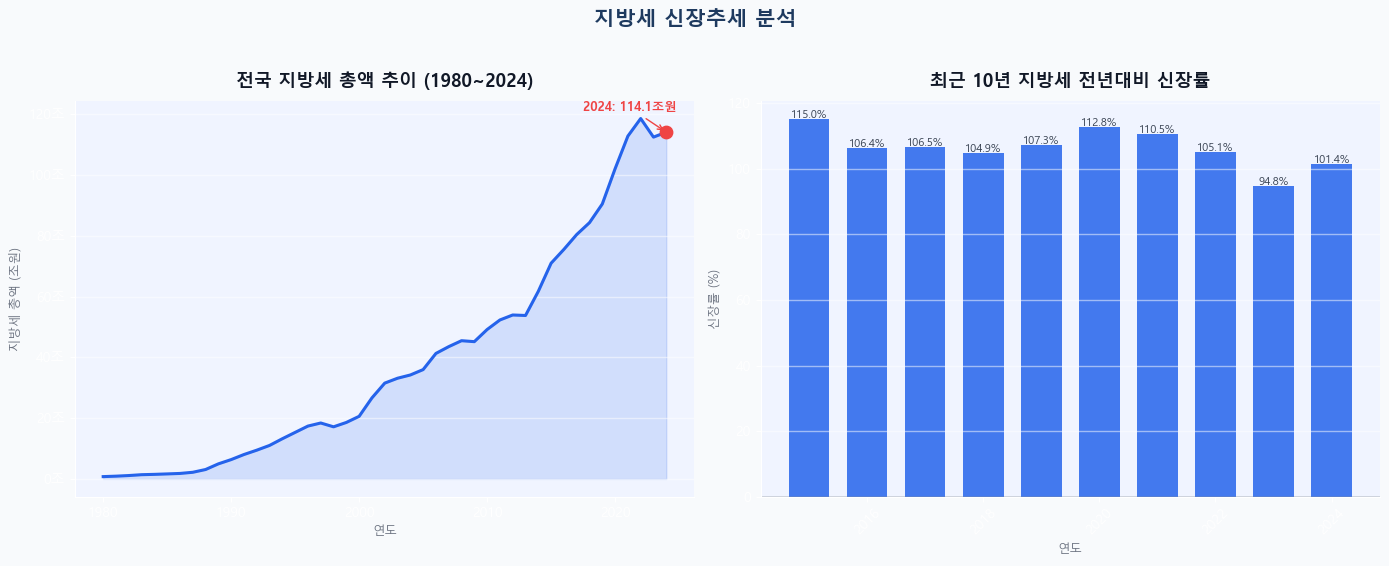

  저장: images\그래프01_지방세신장추세.png


In [10]:
# ════════════════════════════════════════════════════════
# 차트 01 — 지방세 총액 추이 (1980~2024)
# ════════════════════════════════════════════════════════
print('[차트 01] 지방세 총액 추이 생성 중...')

df_c1 = df_t1.copy()
df_c1['연도'] = df_c1['연도'].astype(int)
df_c1['금액_조원'] = pd.to_numeric(df_c1['금액(백만원)'], errors='coerce') / 1e6
df_c1 = df_c1.dropna(subset=['금액_조원'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#F8FAFC')

# 왼쪽: 전체 추이
ax1 = axes[0]
ax1.set_facecolor('#F0F4FF')
ax1.fill_between(df_c1['연도'], df_c1['금액_조원'], alpha=0.15, color='#2563EB')
ax1.plot(df_c1['연도'], df_c1['금액_조원'], color='#2563EB', lw=2.2, zorder=5)
ax1.scatter([2024], df_c1[df_c1['연도']==2024]['금액_조원'],
            color='#EF4444', s=80, zorder=6)
ax1.set_title('전국 지방세 총액 추이 (1980~2024)', fontsize=13,
              fontweight='bold', color='#111827', pad=10)
ax1.set_xlabel('연도', fontsize=9, color='#6B7280')
ax1.set_ylabel('지방세 총액 (조원)', fontsize=9, color='#6B7280')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}조'))
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', color='white', lw=1)
# 2024 레이블
v2024 = df_c1[df_c1['연도']==2024]['금액_조원'].values[0]
ax1.annotate(f'2024: {v2024:.1f}조원', xy=(2024, v2024),
             xytext=(-60, 15), textcoords='offset points',
             fontsize=9, color='#EF4444', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#EF4444', lw=1))

# 오른쪽: 최근 10년 (2015~2024) 전년대비 신장률
ax2 = axes[1]
ax2.set_facecolor('#F0F4FF')
recent = df_c1[df_c1['연도'] >= 2015].copy()
recent['신장률'] = pd.to_numeric(df_c1[df_c1['연도']>=2015]['전년대비 신장률(%)'], errors='coerce')
colors_bar = ['#EF4444' if v < 0 else '#2563EB' for v in recent['신장률']]
bars = ax2.bar(recent['연도'], recent['신장률'], color=colors_bar, width=0.7, alpha=0.85)
ax2.axhline(0, color='#374151', lw=1)
for b in bars:
    h = b.get_height()
    ax2.text(b.get_x()+b.get_width()/2, h + (0.3 if h>=0 else -0.7),
             f'{h:.1f}%', ha='center', fontsize=8, color='#374151')
ax2.set_title('최근 10년 지방세 전년대비 신장률', fontsize=13,
              fontweight='bold', color='#111827', pad=10)
ax2.set_xlabel('연도', fontsize=9, color='#6B7280')
ax2.set_ylabel('신장률 (%)', fontsize=9, color='#6B7280')
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', color='white', lw=1)
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('지방세 신장추세 분석', fontsize=15, fontweight='bold',
             color='#1E3A5F', y=1.02)
plt.tight_layout()

path_c1 = os.path.join(IMAGE_DIR, '그래프01_지방세신장추세.png')
plt.savefig(path_c1, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'  저장: {path_c1}')

[차트 02] 세목별 지방세 금액 비교 생성 중...


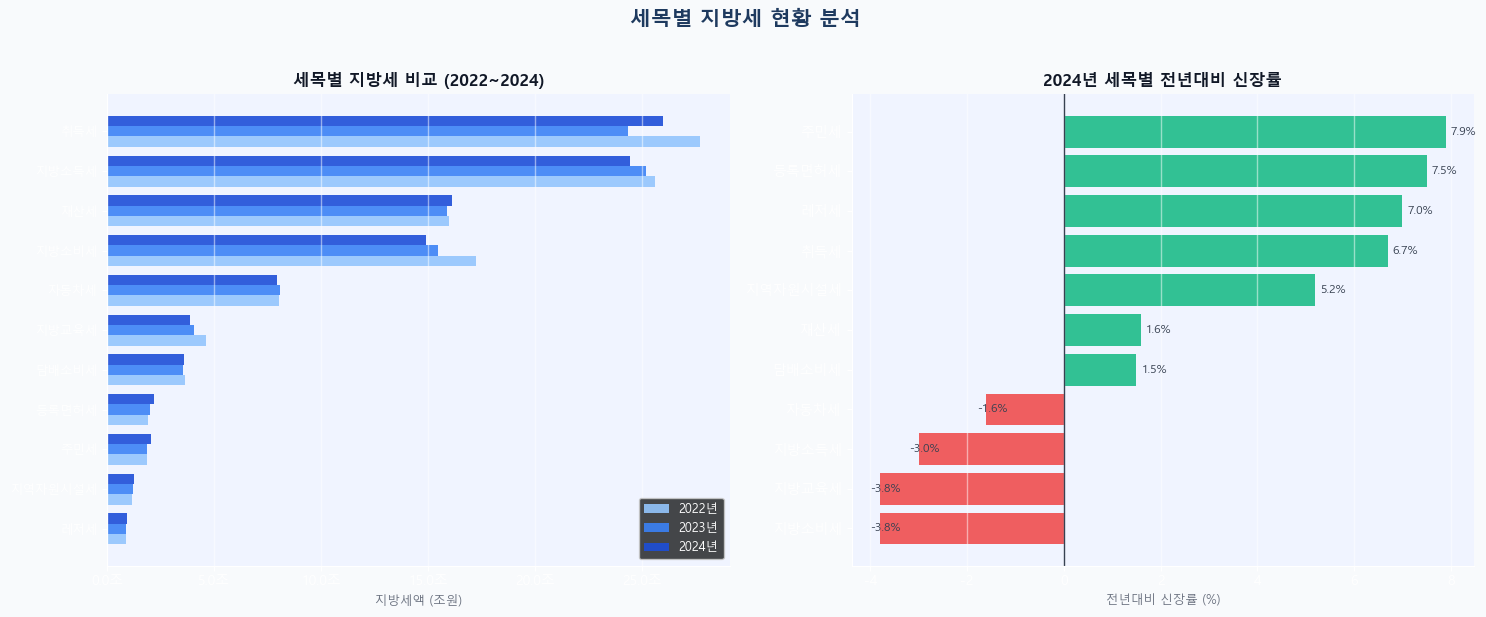

  저장: images\그래프02_세목별지방세비교.png


In [11]:
# ════════════════════════════════════════════════════════
# 차트 02 — 세목별 지방세 금액 비교 (2022~2024)
# ════════════════════════════════════════════════════════
print('[차트 02] 세목별 지방세 금액 비교 생성 중...')

df_c2 = df_t2[df_t2['세목'] != '합 계'].copy()
years  = ['2022','2023','2024']
amount_cols = [f'금액_{y}' for y in years]

# 백만원 → 조원
for c in amount_cols:
    df_c2[c] = pd.to_numeric(df_c2[c], errors='coerce') / 1e6

df_c2 = df_c2.dropna(subset=[amount_cols[0]])
df_c2 = df_c2.sort_values('금액_2024', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#F8FAFC')

# 왼쪽: 세목별 금액 수평 막대
ax1 = axes[0]; ax1.set_facecolor('#F0F4FF')
x = np.arange(len(df_c2))
w = 0.26
colors3 = ['#93C5FD','#3B82F6','#1D4ED8']
for i,(yr,c,col) in enumerate(zip(years, amount_cols, colors3)):
    ax1.barh(x + i*w, df_c2[c], height=w, label=f'{yr}년',
             color=col, alpha=0.9)
ax1.set_yticks(x + w)
ax1.set_yticklabels(df_c2['세목'], fontsize=9)
ax1.set_xlabel('지방세액 (조원)', fontsize=9, color='#6B7280')
ax1.set_title('세목별 지방세 비교 (2022~2024)', fontsize=12,
              fontweight='bold', color='#111827')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}조'))
ax1.spines[['top','right']].set_visible(False)
ax1.set_facecolor('#F0F4FF'); ax1.grid(axis='x', color='white', lw=1)
ax1.legend(fontsize=9)

# 오른쪽: 2024년 세목별 신장률
ax2 = axes[1]; ax2.set_facecolor('#F0F4FF')
df_r = df_t2[df_t2['세목'] != '합 계'].copy()
df_r['신장률_2024(%)'] = pd.to_numeric(df_r['신장률_2024(%)'], errors='coerce')
df_r = df_r.dropna(subset=['신장률_2024(%)'])
df_r = df_r.sort_values('신장률_2024(%)')
bar_colors = ['#EF4444' if v < 0 else '#10B981' for v in df_r['신장률_2024(%)']]
ax2.barh(df_r['세목'], df_r['신장률_2024(%)'], color=bar_colors, alpha=0.85)
ax2.axvline(0, color='#374151', lw=1)
for i, (_, row) in enumerate(df_r.iterrows()):
    v = row['신장률_2024(%)']
    ax2.text(v + (0.1 if v>=0 else -0.2), i, f'{v:.1f}%',
             va='center', fontsize=8.5, color='#374151')
ax2.set_xlabel('전년대비 신장률 (%)', fontsize=9, color='#6B7280')
ax2.set_title('2024년 세목별 전년대비 신장률', fontsize=12,
              fontweight='bold', color='#111827')
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='x', color='white', lw=1)

plt.suptitle('세목별 지방세 현황 분석', fontsize=15, fontweight='bold',
             color='#1E3A5F', y=1.02)
plt.tight_layout()

path_c2 = os.path.join(IMAGE_DIR, '그래프02_세목별지방세비교.png')
plt.savefig(path_c2, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'  저장: {path_c2}')

[차트 03] 시도별 지방세 구성비 생성 중...


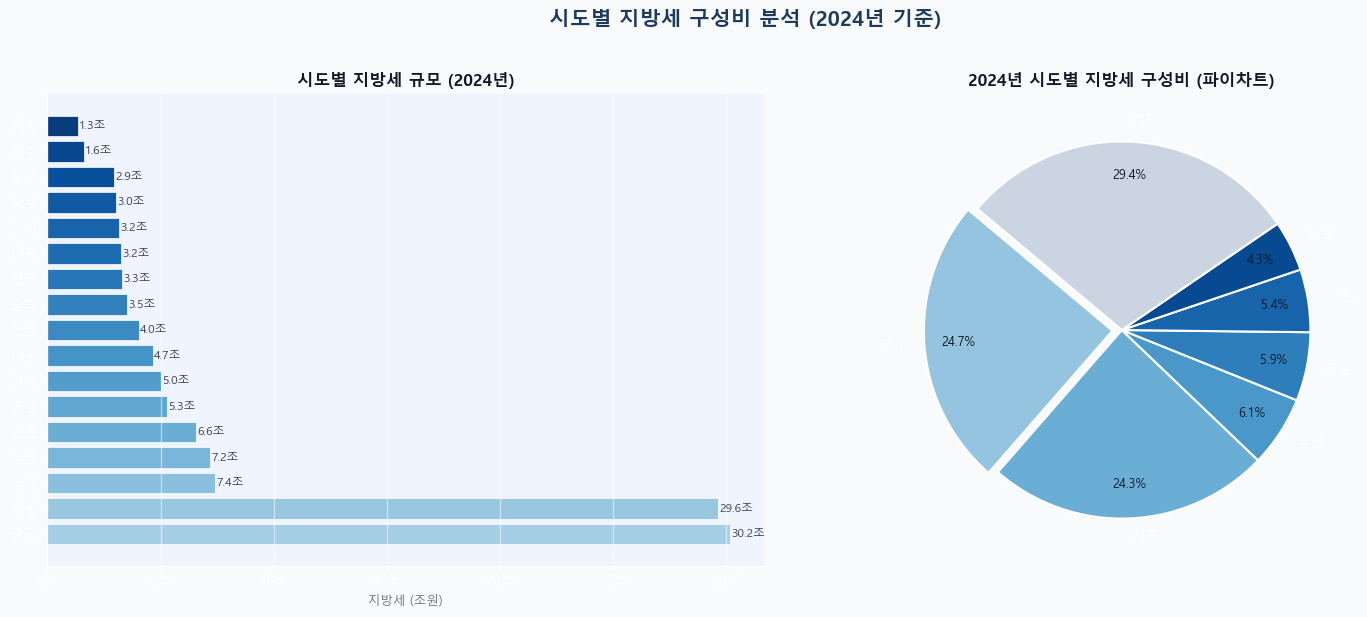

  저장: images\그래프03_시도별구성비.png


In [12]:
# ════════════════════════════════════════════════════════
# 차트 03 — 시도별 지방세 구성비 (2024)
# ════════════════════════════════════════════════════════
print('[차트 03] 시도별 지방세 구성비 생성 중...')

df_c3 = df_t3.copy()
df_c3['금액_조원'] = df_c3['2024년 세수(백만원)'] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#F8FAFC')

# 왼쪽: 수평 막대
ax1 = axes[0]; ax1.set_facecolor('#F0F4FF')
pal = plt.cm.Blues(np.linspace(0.35, 0.95, len(df_c3)))
bars = ax1.barh(df_c3['시도'], df_c3['금액_조원'],
                color=pal, edgecolor='white', lw=0.5)
for b, v in zip(bars, df_c3['금액_조원']):
    ax1.text(v + 0.05, b.get_y()+b.get_height()/2,
             f'{v:.1f}조', va='center', fontsize=8.5, color='#374151')
ax1.set_xlabel('지방세 (조원)', fontsize=9, color='#6B7280')
ax1.set_title('시도별 지방세 규모 (2024년)', fontsize=12,
              fontweight='bold', color='#111827')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}조'))
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='x', color='white', lw=1)

# 오른쪽: 파이차트 (상위 6 + 기타)
ax2 = axes[1]
top6  = df_c3.head(6)
other = df_c3.iloc[6:]['금액_조원'].sum()
pie_vals  = list(top6['금액_조원']) + [other]
pie_labels= list(top6['시도']) + ['기타']
pie_colors = list(plt.cm.Blues(np.linspace(0.4, 0.9, 6))) + ['#CBD5E1']
explode = [0.05 if i == 0 else 0 for i in range(len(pie_vals))]
wedges, texts, autotexts = ax2.pie(
    pie_vals, labels=pie_labels, colors=pie_colors,
    autopct='%1.1f%%', explode=explode,
    pctdistance=0.82, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for t in autotexts:
    t.set_fontsize(9); t.set_color('#111827')
ax2.set_title('2024년 시도별 지방세 구성비 (파이차트)', fontsize=12,
              fontweight='bold', color='#111827')

plt.suptitle('시도별 지방세 구성비 분석 (2024년 기준)', fontsize=15,
             fontweight='bold', color='#1E3A5F', y=1.02)
plt.tight_layout()

path_c3 = os.path.join(IMAGE_DIR, '그래프03_시도별구성비.png')
plt.savefig(path_c3, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'  저장: {path_c3}')

[차트 04] 세목별 지방세 비중 추이 생성 중...


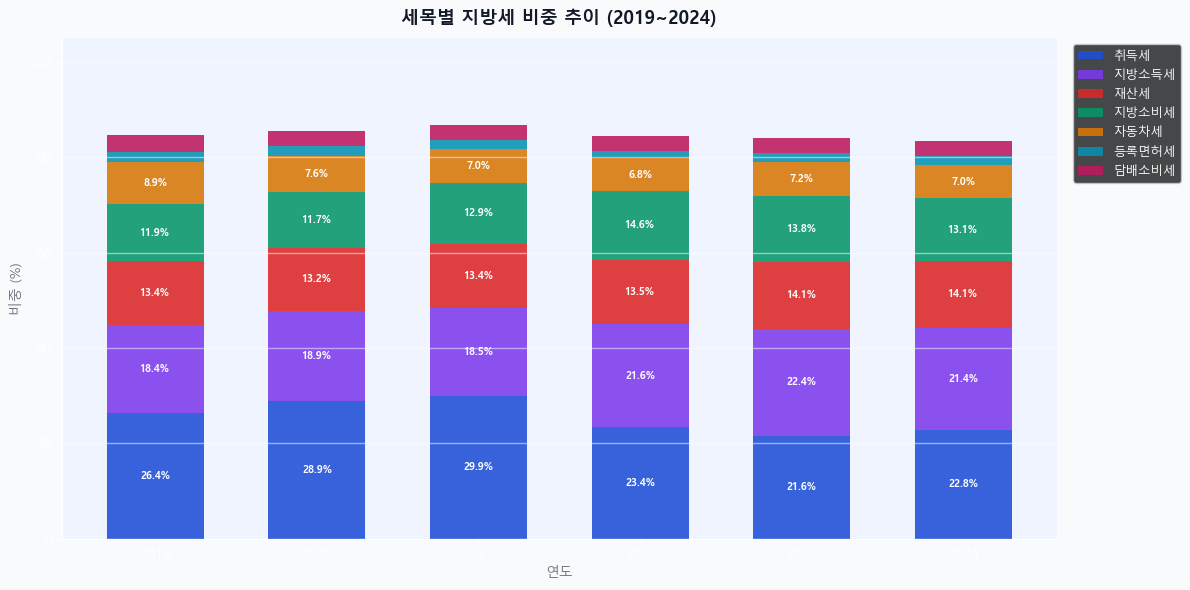

  저장: images\그래프04_세목별비중추이.png


In [13]:
# ════════════════════════════════════════════════════════
# 차트 04 — 세목별 지방세 비중 추이 (스택 영역 차트)
# ════════════════════════════════════════════════════════
print('[차트 04] 세목별 지방세 비중 추이 생성 중...')

tax_sel = ['취득세','지방소득세','재산세','지방소비세',
           '자동차세','등록면허세','담배소비세','기타']

# 2019~2024 금액 데이터
yr_list = ['2019','2020','2021','2022','2023','2024']
df_main = df_t2[df_t2['세목'] != '합 계'].copy()

main_taxes = ['취득세','지방소득세','재산세','지방소비세',
              '자동차세','등록면허세','담배소비세']

stack_data = {}
total_vals = []
for yr in yr_list:
    col = f'금액_{yr}'
    t = df_t2[df_t2['세목']=='합 계'][col].values[0] if col in df_t2.columns else None
    total_vals.append(pd.to_numeric(t, errors='coerce') if t else None)

for tax in main_taxes:
    row = df_main[df_main['세목']==tax]
    vals = []
    for yr in yr_list:
        col = f'금액_{yr}'
        if not row.empty and col in row.columns:
            vals.append(pd.to_numeric(row[col].values[0], errors='coerce'))
        else:
            vals.append(None)
    stack_data[tax] = vals

# 비중 계산
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8FAFC'); ax.set_facecolor('#F0F4FF')

colors_stack = ['#1D4ED8','#7C3AED','#DC2626','#059669',
                '#D97706','#0891B2','#BE185D']

pct_data = {}
for tax in main_taxes:
    pct = []
    for i, yr in enumerate(yr_list):
        v = stack_data[tax][i]
        tot = total_vals[i]
        pct.append(v/tot*100 if (v and tot) else 0)
    pct_data[tax] = pct

bottom = np.zeros(len(yr_list))
for tax, col in zip(main_taxes, colors_stack):
    vals = np.array(pct_data[tax])
    ax.bar(yr_list, vals, bottom=bottom, label=tax, color=col, alpha=0.88, width=0.6)
    # 레이블 (5% 초과만)
    for i, v in enumerate(vals):
        if v > 5:
            ax.text(i, bottom[i]+v/2, f'{v:.1f}%',
                    ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bottom += vals

ax.set_ylim(0, 105)
ax.set_xlabel('연도', fontsize=10, color='#6B7280')
ax.set_ylabel('비중 (%)', fontsize=10, color='#6B7280')
ax.set_title('세목별 지방세 비중 추이 (2019~2024)', fontsize=13,
             fontweight='bold', color='#111827', pad=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', color='white', lw=1)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()

path_c4 = os.path.join(IMAGE_DIR, '그래프04_세목별비중추이.png')
plt.savefig(path_c4, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'  저장: {path_c4}')

[차트 05] 세목별 징수율 비교 생성 중...


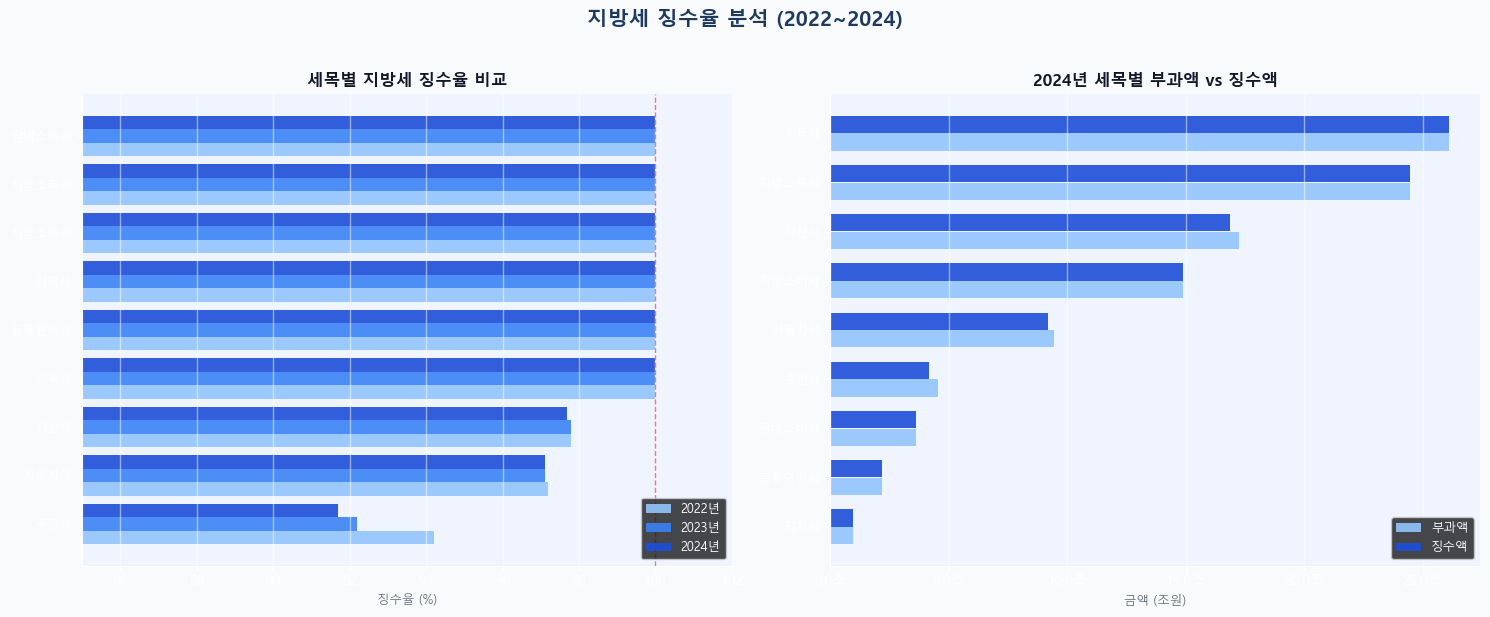

  저장: images\그래프05_징수율비교.png


In [14]:
# ════════════════════════════════════════════════════════
# 차트 05 — 세목별 징수율 비교 (2022~2024)
# ════════════════════════════════════════════════════════
print('[차트 05] 세목별 징수율 비교 생성 중...')

df_c5 = df_t5[df_t5['세목'] != '합 계'].copy()
for c in ['징수율_2022','징수율_2023','징수율_2024']:
    df_c5[c] = pd.to_numeric(df_c5[c], errors='coerce')
df_c5 = df_c5.dropna(subset=['징수율_2024'])
df_c5 = df_c5.sort_values('징수율_2024')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#F8FAFC')

# 왼쪽: 징수율 막대
ax1 = axes[0]; ax1.set_facecolor('#F0F4FF')
x = np.arange(len(df_c5))
w = 0.28
ax1.barh(x-w,   df_c5['징수율_2022'], height=w, label='2022년', color='#93C5FD', alpha=0.9)
ax1.barh(x,     df_c5['징수율_2023'], height=w, label='2023년', color='#3B82F6', alpha=0.9)
ax1.barh(x+w,   df_c5['징수율_2024'], height=w, label='2024년', color='#1D4ED8', alpha=0.9)
ax1.set_yticks(x); ax1.set_yticklabels(df_c5['세목'], fontsize=9)
ax1.set_xlabel('징수율 (%)', fontsize=9, color='#6B7280')
ax1.set_title('세목별 지방세 징수율 비교', fontsize=12, fontweight='bold', color='#111827')
ax1.set_xlim(85, 102)
ax1.axvline(100, color='#EF4444', lw=1, ls='--', alpha=0.7)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='x', color='white', lw=1); ax1.legend(fontsize=9)

# 오른쪽: 2024년 세목별 징수액 vs 부과액
ax2 = axes[1]; ax2.set_facecolor('#F0F4FF')
df_cs = df_t5[df_t5['세목'] != '합 계'].copy()
for c in ['부과액_2024','징수액_2024']:
    df_cs[c] = pd.to_numeric(df_cs[c], errors='coerce') / 1e6  # 백만원 → 조원
df_cs = df_cs.dropna(subset=['부과액_2024']).sort_values('부과액_2024', ascending=True)
x2 = np.arange(len(df_cs))
ax2.barh(x2-0.18, df_cs['부과액_2024'], height=0.35,
         label='부과액', color='#93C5FD', alpha=0.9)
ax2.barh(x2+0.18, df_cs['징수액_2024'], height=0.35,
         label='징수액', color='#1D4ED8', alpha=0.9)
ax2.set_yticks(x2); ax2.set_yticklabels(df_cs['세목'], fontsize=9)
ax2.set_xlabel('금액 (조원)', fontsize=9, color='#6B7280')
ax2.set_title('2024년 세목별 부과액 vs 징수액', fontsize=12,
              fontweight='bold', color='#111827')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.1f}조'))
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='x', color='white', lw=1); ax2.legend(fontsize=9)

plt.suptitle('지방세 징수율 분석 (2022~2024)', fontsize=15,
             fontweight='bold', color='#1E3A5F', y=1.02)
plt.tight_layout()

path_c5 = os.path.join(IMAGE_DIR, '그래프05_징수율비교.png')
plt.savefig(path_c5, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'  저장: {path_c5}')

[차트 06] 신장률 히트맵 생성 중...


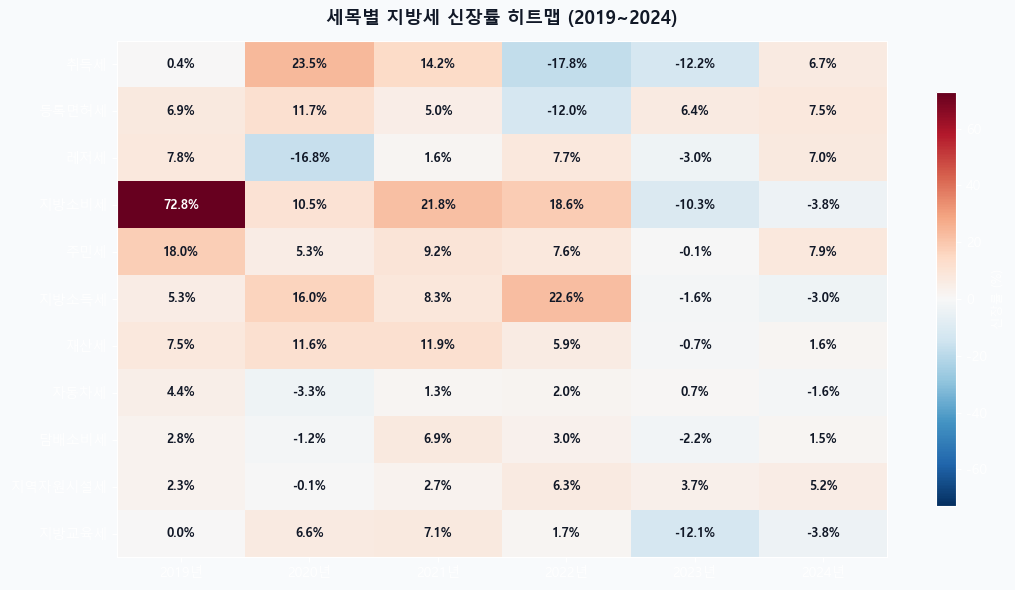

  저장: images\그래프06_신장률히트맵.png


In [15]:
# ════════════════════════════════════════════════════════
# 차트 06 — 지방세 신장률 히트맵 (세목 × 연도)
# ════════════════════════════════════════════════════════
print('[차트 06] 신장률 히트맵 생성 중...')

df_hm = df_t2[df_t2['세목'] != '합 계'].copy().set_index('세목')
rate_cols = [f'신장률_{yr}(%)' for yr in yr_list if f'신장률_{yr}(%)' in df_hm.columns]
df_hm = df_hm[rate_cols].apply(pd.to_numeric, errors='coerce')
df_hm.columns = yr_list[:len(rate_cols)]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F8FAFC')

vmax = max(abs(df_hm.values[~np.isnan(df_hm.values)].max()),
           abs(df_hm.values[~np.isnan(df_hm.values)].min()))

cmap = plt.cm.RdBu_r
im = ax.imshow(df_hm.values, cmap=cmap, aspect='auto',
               vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(df_hm.columns)))
ax.set_xticklabels([f'{y}년' for y in df_hm.columns], fontsize=10)
ax.set_yticks(range(len(df_hm.index)))
ax.set_yticklabels(df_hm.index, fontsize=10)

for i in range(len(df_hm.index)):
    for j in range(len(df_hm.columns)):
        v = df_hm.values[i, j]
        if not np.isnan(v):
            text_color = 'white' if abs(v) > vmax*0.5 else '#111827'
            ax.text(j, i, f'{v:.1f}%', ha='center', va='center',
                    fontsize=9, color=text_color, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('신장률 (%)', fontsize=9)
ax.set_title('세목별 지방세 신장률 히트맵 (2019~2024)', fontsize=13,
             fontweight='bold', color='#111827', pad=12)
plt.tight_layout()

path_c6 = os.path.join(IMAGE_DIR, '그래프06_신장률히트맵.png')
plt.savefig(path_c6, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'  저장: {path_c6}')

In [16]:
# ════════════════════════════════════════════════════════
# 완료 보고
# ════════════════════════════════════════════════════════
from IPython.display import display, HTML
import glob

xlsx_files = sorted(glob.glob(os.path.join(TABLE_DIR, '*.xlsx')))
img_files  = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.png')))

html = f"""
<div style="font-family:sans-serif; padding:16px; background:#F0F9FF;
            border-left:5px solid #2563EB; border-radius:6px;">
  <h3 style="color:#1E3A5F; margin:0 0 12px;">분석 완료 보고</h3>
  <p style="color:#374151;">데이터 원본: <code>input/2025 지방세통계연감.pdf</code> ({len(pdf)}페이지)</p>
  <table style="width:100%; border-collapse:collapse;">
    <tr style="background:#2563EB;">
      <th style="color:white;padding:6px;text-align:left;">구분</th>
      <th style="color:white;padding:6px;">파일 수</th>
      <th style="color:white;padding:6px;text-align:left;">저장 위치</th>
    </tr>
    <tr style="background:#EFF6FF;">
      <td style="padding:6px;">엑셀 tables</td>
      <td style="padding:6px;text-align:center;">{len(xlsx_files)}개</td>
      <td style="padding:6px;"><code>tables/</code></td>
    </tr>
    <tr>
      <td style="padding:6px;">차트 images</td>
      <td style="padding:6px;text-align:center;">{len(img_files)}개</td>
      <td style="padding:6px;"><code>images/</code></td>
    </tr>
  </table>
  <h4 style="color:#1E3A5F; margin:12px 0 6px;">엑셀 파일 목록</h4>
  <ul style="color:#374151; margin:0;">
    {''.join(f'<li><code>{os.path.basename(f)}</code></li>' for f in xlsx_files)}
  </ul>
  <h4 style="color:#1E3A5F; margin:12px 0 6px;">차트 images 목록</h4>
  <ul style="color:#374151; margin:0;">
    {''.join(f'<li><code>{os.path.basename(f)}</code></li>' for f in img_files)}
  </ul>
</div>
"""
display(HTML(html))

구분,파일 수,저장 위치
엑셀 tables,10개,tables/
차트 images,6개,images/
